# City Operational Intelligence & Service Ranking System

This notebook builds a production-ready municipal KPI analytics workflow for Boston's CityScore program.
It loads the raw Excel workbooks, cleans and harmonizes service metrics, applies the requested priority-aware
scoring model, ranks services and departments, generates executive-ready visuals, and exports decision-ready outputs.

## Business Context

CityScore metrics are already normalized around a target-centered score:

- `Score > 1.0`: better than target
- `Score = 1.0`: on target
- `Score < 1.0`: worse than target

The notebook intentionally **does not re-normalize** these scores. It preserves the CityScore logic for both
higher-is-better metrics and lower-is-better metrics, then applies the required operational impact formula:

`Impact Score = (KPI Score - 1) * Priority Weight`

Department scores are then aggregated with:

`Department Score = sum((KPI Score - 1) * Priority Weight) / sum(Priority Weight)`

In [89]:
import os
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns

os.environ.setdefault("MPLCONFIGDIR", str((Path.cwd() / ".matplotlib-cache").resolve()))

import matplotlib.pyplot as plt
from openpyxl.utils import get_column_letter

try:
    from IPython.display import Markdown, display
except ImportError:
    class Markdown(str):
        pass

    def display(obj):
        print(obj)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid", context="talk")

## Configuration, Metric Mapping, and Priority Model

The mappings below encode the business rules supplied in the assignment:

- exact service priority levels and weights
- department ownership groupings
- metric aliases for safe joins across datasets
- service definitions for executive interpretation

In [90]:
PROJECT_ROOT = Path.cwd()
DATA_DIR_CANDIDATES = [PROJECT_ROOT / "Excel", PROJECT_ROOT / "Codes" / "Excel"]
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

INPUT_FILES = {
    "full_metric_list": "CityScore_Full_Metric_list.xlsx",
    "current_summary": "CityScore_Summary.xlsx",
    "historical_summary": "rpt_city_score_summary.csv.xlsx",
    "city_aggregate_history": "rpt_city_score_agg_v.csv.xlsx",
}

SERVICE_PRIORITY_LEVEL = {
    "BFD INCIDENTS": "High",
    "311 CALL CENTER PERFORMANCE": "High",
    "EMS RESPONSE TIME": "High",
    "HOMICIDES (TREND)": "High",
    "SHOOTINGS (TREND)": "High",
    "STABBINGS (TREND)": "High",
    "PART 1 CRIMES": "High",
    "BPS ATTENDANCE": "Medium",
    "POTHOLE ON-TIME %": "Medium",
    "MISSED TRASH ON-TIME %": "Medium",
    "STREETLIGHT ON-TIME %": "Medium",
    "SIGNAL REPAIR ON-TIME %": "Medium",
    "SIGN INSTALLATION ON-TIME %": "Medium",
    "PARKS MAINTENANCE ON-TIME %": "Medium",
    "CODE ENFORCEMENT ON-TIME %": "Medium",
    "ON-TIME PERMIT REVIEWS": "Medium",
    "CITY SERVICES SATISFACTION SURVEYS": "Medium",
    "311 CONSTITUENT EXPERIENCE SURVEYS": "Low",
    "BFD RESPONSE TIME": "Low",
    "CODE ENFORCEMENT TRASH COLLECTION": "Low",
    "TREE MAINTENANCE ON-TIME %": "Low",
    "GRAFFITI ON-TIME %": "Low",
    "LIBRARY USERS": "Low",
}

PRIORITY_WEIGHT = {"High": 3, "Medium": 2, "Low": 1}

SERVICE_TO_DEPARTMENT = {
    "BPS ATTENDANCE": "Boston Public Schools (BPS)",
    "311 CALL CENTER PERFORMANCE": "City Services",
    "311 CONSTITUENT EXPERIENCE SURVEYS": "City Services",
    "CITY SERVICES SATISFACTION SURVEYS": "City Services",
    "EMS RESPONSE TIME": "Emergency Medical Services (EMS)",
    "EMS INCIDENTS": "Emergency Medical Services (EMS)",
    "BFD INCIDENTS": "Fire Department (BFD)",
    "BFD RESPONSE TIME": "Fire Department (BFD)",
    "LIBRARY USERS": "Library Department",
    "ON-TIME PERMIT REVIEWS": "Permitting Department",
    "HOMICIDES (TREND)": "Public Safety / Crime",
    "SHOOTINGS (TREND)": "Public Safety / Crime",
    "STABBINGS (TREND)": "Public Safety / Crime",
    "PART 1 CRIMES": "Public Safety / Crime",
    "GRAFFITI ON-TIME %": "Public Works / Maintenance",
    "POTHOLE ON-TIME %": "Public Works / Maintenance",
    "MISSED TRASH ON-TIME %": "Public Works / Maintenance",
    "STREETLIGHT ON-TIME %": "Public Works / Maintenance",
    "SIGN INSTALLATION ON-TIME %": "Public Works / Maintenance",
    "PARKS MAINTENANCE ON-TIME %": "Public Works / Maintenance",
    "TREE MAINTENANCE ON-TIME %": "Public Works / Maintenance",
    "CODE ENFORCEMENT ON-TIME %": "Public Works / Maintenance",
    "CODE ENFORCEMENT TRASH COLLECTION": "Public Works / Maintenance",
    "SIGNAL REPAIR ON-TIME %": "Traffic Department",
}

METRIC_ALIASES = {
    "CONSTITUENT SATISFACTION SURVEYS": "CITY SERVICES SATISFACTION SURVEYS",
    "GRAFFITI REMOVAL ON-TIME %": "GRAFFITI ON-TIME %",
    "POTHOLE REPAIR ON-TIME %": "POTHOLE ON-TIME %",
}

SERVICE_DEFINITIONS = {
    "311 CALL CENTER PERFORMANCE": "Answer 311 calls within 30 seconds at least 95% of the time.",
    "BFD INCIDENTS": "Higher CityScore means fewer incidents than historical average.",
    "BFD RESPONSE TIME": "First fire truck arrives within 4 minutes at least 90% of the time.",
    "BPS ATTENDANCE": "Target attendance is 95%.",
    "CITY SERVICES SATISFACTION SURVEYS": "Average constituent satisfaction target is 4 out of 5.",
    "EMS INCIDENTS": "Higher CityScore means EMS incidents decreased versus historical average.",
    "EMS RESPONSE TIME": "Median EMS response time target is 6 minutes or less.",
    "GRAFFITI ON-TIME %": "Target is 80% removed within 45 business days.",
    "HOMICIDES (TREND)": "Higher CityScore means homicide levels improved versus historical average.",
    "LIBRARY USERS": "Higher usage is better.",
    "MISSED TRASH ON-TIME %": "Target is 80% inspected within 1 business day.",
    "ON-TIME PERMIT REVIEWS": "Target is 75% reviewed within 20 business days.",
    "PARKS MAINTENANCE ON-TIME %": "Target is 80% completed within required timelines.",
    "PART 1 CRIMES": "Higher CityScore means fewer serious crimes.",
    "POTHOLE ON-TIME %": "Target is 80% repaired within 1 business day.",
    "SHOOTINGS (TREND)": "Higher CityScore means fewer shootings versus historical average.",
    "SIGN INSTALLATION ON-TIME %": "Target is timely installation against the CityScore service standard.",
    "SIGNAL REPAIR ON-TIME %": "Target is 80% repaired within 24 hours.",
    "STABBINGS (TREND)": "Higher CityScore means fewer stabbings versus historical average.",
    "STREETLIGHT ON-TIME %": "Target is timely streetlight repair against the CityScore standard.",
    "TREE MAINTENANCE ON-TIME %": "Target is timely tree maintenance against the CityScore standard.",
    "311 CONSTITUENT EXPERIENCE SURVEYS": "Tracks 311 constituent experience survey performance.",
    "CODE ENFORCEMENT ON-TIME %": "Target is timely code enforcement request resolution.",
    "CODE ENFORCEMENT TRASH COLLECTION": "Tracks operational performance for code enforcement trash collection.",
}

## Helper Functions

These helpers make the notebook resilient to:

- workbook sheet-name changes
- column formatting inconsistencies
- duplicated metric snapshots in the current metric workbook
- missing values in period scores
- mixed numeric, text, and timestamp columns during export

In [91]:
def resolve_input_file(filename: str) -> Path:
    for data_dir in DATA_DIR_CANDIDATES:
        candidate = data_dir / filename
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"Could not locate input workbook: {filename}")


def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    renamed = {}
    for col in df.columns:
        cleaned = re.sub(r"[^0-9a-zA-Z]+", "_", str(col).strip().lower()).strip("_")
        renamed[col] = cleaned
    return df.rename(columns=renamed)


def canonical_metric_name(value) -> str:
    text = "" if pd.isna(value) else str(value)
    text = " ".join(text.upper().split())
    return METRIC_ALIASES.get(text, text)


def load_excel_first_sheet(path: Path) -> pd.DataFrame:
    workbook = pd.ExcelFile(path)
    df = workbook.parse(workbook.sheet_names[0])
    df.attrs["sheet_name"] = workbook.sheet_names[0]
    df.attrs["source_path"] = str(path)
    return df


def keep_latest_metric_snapshot(frame: pd.DataFrame) -> pd.DataFrame:
    working = frame.copy()
    if "score_calculated_ts" in working.columns:
        working["score_calculated_ts"] = pd.to_datetime(working["score_calculated_ts"], errors="coerce")

    if "latest_score_flag" in working.columns and working["latest_score_flag"].fillna(0).eq(1).any():
        latest = working.loc[working["latest_score_flag"].fillna(0).eq(1)].copy()
    elif "score_calculated_ts" in working.columns:
        latest = (
            working.sort_values("score_calculated_ts")
            .groupby("metric_name", as_index=False)
            .tail(1)
            .copy()
        )
    else:
        latest = working.copy()

    return latest.sort_values("metric_name").reset_index(drop=True)


def compute_weighted_score(month_score, quarter_score, week_score, day_score):
    values = {
        "day": day_score,
        "week": week_score,
        "month": month_score,
        "quarter": quarter_score,
    }
    if pd.notna(month_score) and pd.notna(quarter_score):
        return 0.6 * month_score + 0.4 * quarter_score, "0.6*month + 0.4*quarter"
    if pd.notna(month_score):
        return month_score, "month fallback (quarter missing)"
    if pd.notna(week_score):
        return week_score, "week fallback (month unavailable)"

    available = [(period, score) for period, score in values.items() if pd.notna(score)]
    if available:
        period_priority = {"quarter": 4, "month": 3, "week": 2, "day": 1}
        period, score = max(available, key=lambda item: period_priority[item[0]])
        return score, f"latest available fallback: {period}"

    return np.nan, "no score available"


def label_trend(delta: float) -> str:
    if pd.isna(delta):
        return "Unknown"
    if delta > 0.02:
        return "Improving"
    if delta < -0.02:
        return "Deteriorating"
    return "Stable"


def autosize_worksheet(worksheet, dataframe: pd.DataFrame, max_width: int = 45) -> None:
    worksheet.freeze_panes = "A2"
    for idx, col in enumerate(dataframe.columns, start=1):
        if dataframe.empty:
            max_len = len(str(col))
        else:
            max_len = max(
                len(str(col)),
                int(dataframe[col].apply(lambda value: len(str(value)) if pd.notna(value) else 0).max()),
            )
        worksheet.column_dimensions[get_column_letter(idx)].width = min(max_len + 2, max_width)


def department_summary(group: pd.DataFrame) -> pd.Series:
    total_priority = group["priority_weight"].sum()
    total_impact = group["impact_score"].sum()
    department_score = total_impact / total_priority if total_priority else np.nan
    return pd.Series(
        {
            "service_count": int(group["metric_name"].nunique()),
            "total_priority_weight": total_priority,
            "department_impact_total": total_impact,
            "department_score": department_score,
            "average_weighted_kpi_score": group["weighted_kpi_score"].mean(),
            "critical_service_count": int((group["priority_weight"] == 3).sum()),
            "critical_underperformers": int(
                ((group["priority_weight"] == 3) & (group["weighted_kpi_score"] < 1.0)).sum()
            ),
        }
    )


def compute_recent_history_features(frame: pd.DataFrame) -> pd.Series:
    recent = frame.sort_values("as_of_date").tail(6)
    if recent.empty:
        return pd.Series(
            {
                "history_points": 0,
                "history_latest_score": np.nan,
                "history_trend_change_6": np.nan,
            }
        )

    return pd.Series(
        {
            "history_points": int(len(recent)),
            "history_latest_score": recent["score"].iloc[-1],
            "history_trend_change_6": recent["score"].iloc[-1] - recent["score"].iloc[0]
            if len(recent) > 1
            else 0.0,
        }
    )

## Load Datasets

The workflow reads all four Excel inputs directly from the repository and records a small inventory table so
the run can be audited quickly.

In [92]:
raw_full_metrics = load_excel_first_sheet(resolve_input_file(INPUT_FILES["full_metric_list"]))
raw_current_summary = load_excel_first_sheet(resolve_input_file(INPUT_FILES["current_summary"]))
raw_historical_summary = load_excel_first_sheet(resolve_input_file(INPUT_FILES["historical_summary"]))
raw_city_aggregate = load_excel_first_sheet(resolve_input_file(INPUT_FILES["city_aggregate_history"]))

dataset_inventory = pd.DataFrame(
    [
        {
            "dataset": "CityScore_Full_Metric_list",
            "file_path": raw_full_metrics.attrs["source_path"],
            "sheet_name": raw_full_metrics.attrs["sheet_name"],
            "rows": raw_full_metrics.shape[0],
            "columns": raw_full_metrics.shape[1],
        },
        {
            "dataset": "CityScore_Summary",
            "file_path": raw_current_summary.attrs["source_path"],
            "sheet_name": raw_current_summary.attrs["sheet_name"],
            "rows": raw_current_summary.shape[0],
            "columns": raw_current_summary.shape[1],
        },
        {
            "dataset": "rpt_city_score_summary.csv",
            "file_path": raw_historical_summary.attrs["source_path"],
            "sheet_name": raw_historical_summary.attrs["sheet_name"],
            "rows": raw_historical_summary.shape[0],
            "columns": raw_historical_summary.shape[1],
        },
        {
            "dataset": "rpt_city_score_agg_v.csv",
            "file_path": raw_city_aggregate.attrs["source_path"],
            "sheet_name": raw_city_aggregate.attrs["sheet_name"],
            "rows": raw_city_aggregate.shape[0],
            "columns": raw_city_aggregate.shape[1],
        },
    ]
)

display(dataset_inventory)

,dataset,file_path,sheet_name,rows,columns
0,CityScore_Full_Metric_list,/Users/ameyasutar1gmail.com/Desktop/IIMA/pytho...,tmpo_89xhbb,115,17
1,CityScore_Summary,/Users/ameyasutar1gmail.com/Desktop/IIMA/pytho...,tmpm1fv_p3u,23,8
2,rpt_city_score_summary.csv,/Users/ameyasutar1gmail.com/Desktop/IIMA/pytho...,rpt_city_score_summary,18235,23
3,rpt_city_score_agg_v.csv,/Users/ameyasutar1gmail.com/Desktop/IIMA/pytho...,rpt_city_score_agg_v,844,6


## Data Cleaning and Harmonization

The current metric workbook contains repeated metric snapshots, so the notebook keeps only the latest current
observation per metric before merging. Historical datasets are transformed into both latest-snapshot and long-format
views for scoring and trend diagnostics.

In [93]:
full_metrics = normalize_columns(raw_full_metrics)
full_metrics["metric_name"] = full_metrics["metric_name"].map(canonical_metric_name)
full_metrics = keep_latest_metric_snapshot(full_metrics)
for column in ["day_score", "week_score", "month_score", "quarter_score", "target"]:
    if column in full_metrics.columns:
        full_metrics[column] = pd.to_numeric(full_metrics[column], errors="coerce")
if "score_calculated_ts" in full_metrics.columns:
    full_metrics["score_calculated_ts"] = pd.to_datetime(full_metrics["score_calculated_ts"], errors="coerce")

current_summary = normalize_columns(raw_current_summary)
current_summary["metric_name"] = current_summary["metric_name"].map(canonical_metric_name)
for column in ["previous_day_score", "previous_week_score", "previous_month_score", "previous_quarter_score"]:
    if column in current_summary.columns:
        current_summary[column] = pd.to_numeric(current_summary[column], errors="coerce")
if "score_calculated_ts" in current_summary.columns:
    current_summary["score_calculated_ts"] = pd.to_datetime(current_summary["score_calculated_ts"], errors="coerce")
if "score_final_table_ts" in current_summary.columns:
    current_summary["score_final_table_ts"] = pd.to_datetime(
        current_summary["score_final_table_ts"], errors="coerce"
    )

historical_summary = normalize_columns(raw_historical_summary)
historical_summary["metric_name"] = historical_summary["cty_scr_name"].map(canonical_metric_name)
historical_summary["etl_load_date"] = pd.to_datetime(historical_summary["etl_load_date"], errors="coerce")
for column in ["cty_scr_day", "cty_scr_week", "cty_scr_month", "cty_scr_quarter"]:
    historical_summary[column] = pd.to_numeric(historical_summary[column], errors="coerce")

latest_historical_snapshot = (
    historical_summary.sort_values("etl_load_date")
    .groupby("metric_name", as_index=False)
    .tail(1)[
        [
            "metric_name",
            "etl_load_date",
            "cty_scr_day",
            "cty_scr_week",
            "cty_scr_month",
            "cty_scr_quarter",
            "cty_scr_metric_type",
            "cty_scr_open_data_source",
        ]
    ]
    .rename(
        columns={
            "etl_load_date": "latest_history_date",
            "cty_scr_day": "history_day_score",
            "cty_scr_week": "history_week_score",
            "cty_scr_month": "history_month_score",
            "cty_scr_quarter": "history_quarter_score",
            "cty_scr_metric_type": "history_metric_type",
            "cty_scr_open_data_source": "history_open_data_source",
        }
    )
)

historical_metric_history = pd.concat(
    [
        historical_summary[["metric_name", "etl_load_date", "cty_scr_day"]]
        .rename(columns={"etl_load_date": "as_of_date", "cty_scr_day": "score"})
        .assign(period_type="day"),
        historical_summary[["metric_name", "etl_load_date", "cty_scr_week"]]
        .rename(columns={"etl_load_date": "as_of_date", "cty_scr_week": "score"})
        .assign(period_type="week"),
        historical_summary[["metric_name", "etl_load_date", "cty_scr_month"]]
        .rename(columns={"etl_load_date": "as_of_date", "cty_scr_month": "score"})
        .assign(period_type="month"),
        historical_summary[["metric_name", "etl_load_date", "cty_scr_quarter"]]
        .rename(columns={"etl_load_date": "as_of_date", "cty_scr_quarter": "score"})
        .assign(period_type="quarter"),
    ],
    ignore_index=True,
).dropna(subset=["score"])

city_aggregate_history = normalize_columns(raw_city_aggregate)
city_aggregate_history["etl_load_date"] = pd.to_datetime(city_aggregate_history["etl_load_date"], errors="coerce")
for column in ["cty_scr_day_agg", "cty_scr_week_agg", "cty_scr_month_agg", "cty_scr_quarter_agg"]:
    city_aggregate_history[column] = pd.to_numeric(city_aggregate_history[column], errors="coerce")

citywide_history = pd.concat(
    [
        city_aggregate_history[["etl_load_date", "cty_scr_day_agg"]]
        .rename(columns={"etl_load_date": "as_of_date", "cty_scr_day_agg": "score"})
        .assign(period_type="day"),
        city_aggregate_history[["etl_load_date", "cty_scr_week_agg"]]
        .rename(columns={"etl_load_date": "as_of_date", "cty_scr_week_agg": "score"})
        .assign(period_type="week"),
        city_aggregate_history[["etl_load_date", "cty_scr_month_agg"]]
        .rename(columns={"etl_load_date": "as_of_date", "cty_scr_month_agg": "score"})
        .assign(period_type="month"),
        city_aggregate_history[["etl_load_date", "cty_scr_quarter_agg"]]
        .rename(columns={"etl_load_date": "as_of_date", "cty_scr_quarter_agg": "score"})
        .assign(period_type="quarter"),
    ],
    ignore_index=True,
).dropna(subset=["score"])

historical_only_metrics = sorted(set(historical_summary["metric_name"]) - set(full_metrics["metric_name"]))

data_quality_summary = pd.DataFrame(
    [
        {"table": "full_metrics_latest_snapshot", "rows": len(full_metrics), "columns": full_metrics.shape[1]},
        {"table": "current_summary", "rows": len(current_summary), "columns": current_summary.shape[1]},
        {
            "table": "latest_historical_snapshot",
            "rows": len(latest_historical_snapshot),
            "columns": latest_historical_snapshot.shape[1],
        },
        {
            "table": "historical_metric_history",
            "rows": len(historical_metric_history),
            "columns": historical_metric_history.shape[1],
        },
        {"table": "citywide_history", "rows": len(citywide_history), "columns": citywide_history.shape[1]},
    ]
)

if full_metrics["metric_name"].duplicated().any():
    raise ValueError("The latest metric snapshot still contains duplicate metric names after filtering.")

display(data_quality_summary)
print("Historical-only metrics not used in the current service ranking:", historical_only_metrics)

,table,rows,columns
0,full_metrics_latest_snapshot,23,17
1,current_summary,23,8
2,latest_historical_snapshot,22,8
3,historical_metric_history,68184,4
4,citywide_history,3376,3


Historical-only metrics not used in the current service ranking: ['EMS INCIDENTS']


## Metric Mapping, Department Mapping, and Priority Assignment

Every current service metric is assigned to a department and a business priority level. Historical-only metrics
are retained for context but excluded from current service rankings if they do not appear in the latest snapshot.

In [94]:
service_priority_table = (
    pd.DataFrame({"metric_name": sorted(SERVICE_PRIORITY_LEVEL)})
    .assign(
        department=lambda frame: frame["metric_name"].map(SERVICE_TO_DEPARTMENT),
        priority_level=lambda frame: frame["metric_name"].map(SERVICE_PRIORITY_LEVEL),
        priority_weight=lambda frame: frame["priority_level"].map(PRIORITY_WEIGHT),
        service_definition=lambda frame: frame["metric_name"].map(SERVICE_DEFINITIONS),
    )
    .sort_values(["priority_weight", "department", "metric_name"], ascending=[False, True, True])
    .reset_index(drop=True)
)

display(service_priority_table)

,metric_name,department,priority_level,priority_weight,service_definition
0,311 CALL CENTER PERFORMANCE,City Services,High,3,Answer 311 calls within 30 seconds at least 95...
1,EMS RESPONSE TIME,Emergency Medical Services (EMS),High,3,Median EMS response time target is 6 minutes o...
2,BFD INCIDENTS,Fire Department (BFD),High,3,Higher CityScore means fewer incidents than hi...
3,HOMICIDES (TREND),Public Safety / Crime,High,3,Higher CityScore means homicide levels improve...
4,PART 1 CRIMES,Public Safety / Crime,High,3,Higher CityScore means fewer serious crimes.
5,SHOOTINGS (TREND),Public Safety / Crime,High,3,Higher CityScore means fewer shootings versus ...
6,STABBINGS (TREND),Public Safety / Crime,High,3,Higher CityScore means fewer stabbings versus ...
7,BPS ATTENDANCE,Boston Public Schools (BPS),Medium,2,Target attendance is 95%.
8,CITY SERVICES SATISFACTION SURVEYS,City Services,Medium,2,Average constituent satisfaction target is 4 o...
9,ON-TIME PERMIT REVIEWS,Permitting Department,Medium,2,Target is 75% reviewed within 20 business days.


## KPI Score Calculation and Trend Diagnostics

The notebook follows the exact scoring logic requested:

1. Use `0.6 * monthly + 0.4 * quarterly` when both are available.
2. If quarterly is unavailable, use monthly only.
3. If monthly is unavailable, use weekly.
4. If both are unavailable, use the latest available score.

Previous-period composite scores are calculated with the same fallback chain to create a simple trend delta and
trend label for each service.

In [95]:
clean_merged_dataset = (
    full_metrics.merge(current_summary, on="metric_name", how="left", suffixes=("", "_summary"))
    .merge(latest_historical_snapshot, on="metric_name", how="left")
)

for period in ["day", "week", "month", "quarter"]:
    score_col = f"{period}_score"
    history_col = f"history_{period}_score"
    if history_col in clean_merged_dataset.columns:
        clean_merged_dataset[score_col] = clean_merged_dataset[score_col].combine_first(
            clean_merged_dataset[history_col]
        )

clean_merged_dataset["department"] = clean_merged_dataset["metric_name"].map(SERVICE_TO_DEPARTMENT).fillna(
    "Unmapped Department"
)
clean_merged_dataset["priority_level"] = clean_merged_dataset["metric_name"].map(SERVICE_PRIORITY_LEVEL)
clean_merged_dataset["priority_weight"] = clean_merged_dataset["priority_level"].map(PRIORITY_WEIGHT)
clean_merged_dataset["operational_importance"] = clean_merged_dataset["priority_weight"]
clean_merged_dataset["service_definition"] = clean_merged_dataset["metric_name"].map(SERVICE_DEFINITIONS).fillna(
    "Service definition not provided in the business brief."
)
clean_merged_dataset["in_scope_for_ranking"] = clean_merged_dataset["priority_weight"].notna()

current_score_result = clean_merged_dataset.apply(
    lambda row: compute_weighted_score(
        row.get("month_score"),
        row.get("quarter_score"),
        row.get("week_score"),
        row.get("day_score"),
    ),
    axis=1,
)
clean_merged_dataset["weighted_kpi_score"] = current_score_result.map(lambda item: item[0])
clean_merged_dataset["score_selection_method"] = current_score_result.map(lambda item: item[1])

previous_score_result = clean_merged_dataset.apply(
    lambda row: compute_weighted_score(
        row.get("previous_month_score"),
        row.get("previous_quarter_score"),
        row.get("previous_week_score"),
        row.get("previous_day_score"),
    ),
    axis=1,
)
clean_merged_dataset["previous_weighted_kpi_score"] = previous_score_result.map(lambda item: item[0])
clean_merged_dataset["previous_score_method"] = previous_score_result.map(lambda item: item[1])

clean_merged_dataset["performance_vs_target"] = clean_merged_dataset["weighted_kpi_score"] - 1.0
clean_merged_dataset["impact_score"] = (
    clean_merged_dataset["performance_vs_target"] * clean_merged_dataset["priority_weight"]
)
clean_merged_dataset["trend_delta"] = (
    clean_merged_dataset["weighted_kpi_score"] - clean_merged_dataset["previous_weighted_kpi_score"]
)
clean_merged_dataset["trend_label"] = clean_merged_dataset["trend_delta"].map(label_trend)
clean_merged_dataset["monthly_quarterly_gap"] = (
    clean_merged_dataset["month_score"] - clean_merged_dataset["quarter_score"]
)
clean_merged_dataset["underperforming_critical_service"] = (
    (clean_merged_dataset["priority_weight"] == 3)
    & (clean_merged_dataset["weighted_kpi_score"] < 1.0)
)
clean_merged_dataset["snapshot_date"] = (
    clean_merged_dataset[["score_final_table_ts", "score_calculated_ts"]]
    .bfill(axis=1)
    .iloc[:, 0]
    .dt.date
)

monthly_history_features = (
    historical_metric_history.loc[historical_metric_history["period_type"] == "month"]
    .groupby("metric_name", dropna=False)
    .apply(compute_recent_history_features)
    .reset_index()
)
clean_merged_dataset = clean_merged_dataset.merge(monthly_history_features, on="metric_name", how="left")

service_kpi_table = (
    clean_merged_dataset.loc[
        clean_merged_dataset["in_scope_for_ranking"] & clean_merged_dataset["weighted_kpi_score"].notna(),
        [
            "metric_name",
            "department",
            "priority_level",
            "priority_weight",
            "operational_importance",
            "weighted_kpi_score",
            "previous_weighted_kpi_score",
            "trend_delta",
            "trend_label",
            "performance_vs_target",
            "impact_score",
            "score_selection_method",
            "month_score",
            "quarter_score",
            "week_score",
            "day_score",
            "history_points",
            "history_latest_score",
            "history_trend_change_6",
            "target",
            "metric_logic",
            "service_definition",
            "snapshot_date",
        ],
    ]
    .sort_values(["impact_score", "weighted_kpi_score"], ascending=[False, False])
    .reset_index(drop=True)
)
service_kpi_table.insert(0, "service_rank", np.arange(1, len(service_kpi_table) + 1))

display(
    service_kpi_table[
        [
            "service_rank",
            "metric_name",
            "department",
            "priority_level",
            "weighted_kpi_score",
            "trend_label",
            "impact_score",
        ]
    ].round(4)
)

,service_rank,metric_name,department,priority_level,weighted_kpi_score,trend_label,impact_score
0,1,HOMICIDES (TREND),Public Safety / Crime,High,9.2934,Improving,24.8803
1,2,SHOOTINGS (TREND),Public Safety / Crime,High,1.4367,Stable,1.3100
2,3,LIBRARY USERS,Library Department,Low,1.7695,Stable,0.7695
3,4,CODE ENFORCEMENT ON-TIME %,Public Works / Maintenance,Medium,1.2268,Stable,0.4536
4,5,MISSED TRASH ON-TIME %,Public Works / Maintenance,Medium,1.1987,Stable,0.3974
5,6,SIGNAL REPAIR ON-TIME %,Traffic Department,Medium,1.1845,Stable,0.3689
6,7,STABBINGS (TREND),Public Safety / Crime,High,1.1139,Stable,0.3416
7,8,CODE ENFORCEMENT TRASH COLLECTION,Public Works / Maintenance,Low,1.1963,Stable,0.1963
8,9,TREE MAINTENANCE ON-TIME %,Public Works / Maintenance,Low,1.1860,Unknown,0.1860
9,10,311 CONSTITUENT EXPERIENCE SURVEYS,City Services,Low,1.1298,Stable,0.1298


## Operational Impact Scores, Department Aggregation, and Rankings

Service rankings are based on the required operational impact formula.
Department rankings use the required weighted aggregation formula so that critical services exert more influence
than low-priority services.

In [96]:
operational_impact_score_table = service_kpi_table[
    [
        "service_rank",
        "metric_name",
        "department",
        "priority_level",
        "priority_weight",
        "weighted_kpi_score",
        "performance_vs_target",
        "impact_score",
        "trend_label",
        "trend_delta",
    ]
].copy()

department_score_table = (
    service_kpi_table.groupby("department", dropna=False)
    .apply(department_summary)
    .reset_index()
    .sort_values(["department_score", "department_impact_total"], ascending=[False, False])
    .reset_index(drop=True)
)
department_score_table.insert(0, "department_rank", np.arange(1, len(department_score_table) + 1))
department_score_table["department_status"] = np.where(
    department_score_table["department_score"] >= 0,
    "Above Target",
    "Needs Intervention",
)

top_5_services = service_kpi_table.head(5).copy()
bottom_5_services = service_kpi_table.tail(5).sort_values("impact_score").reset_index(drop=True)
best_performing_departments = department_score_table.head(5).copy()
worst_performing_departments = (
    department_score_table.tail(5).sort_values("department_score").reset_index(drop=True)
)
critical_underperformers = (
    service_kpi_table.loc[
        (service_kpi_table["priority_weight"] == 3) & (service_kpi_table["weighted_kpi_score"] < 1.0)
    ]
    .sort_values("impact_score")
    .reset_index(drop=True)
)

print("Top 5 Best Performing Services")
display(top_5_services[["service_rank", "metric_name", "department", "weighted_kpi_score", "impact_score"]].round(4))

print("Bottom 5 Worst Performing Services")
display(bottom_5_services[["service_rank", "metric_name", "department", "weighted_kpi_score", "impact_score"]].round(4))

print("Department Ranking")
display(department_score_table.round(4))

print("Critical High-Priority Services That Are Underperforming")
display(
    critical_underperformers[
        ["service_rank", "metric_name", "department", "weighted_kpi_score", "impact_score", "trend_label"]
    ].round(4)
)

Top 5 Best Performing Services


,service_rank,metric_name,department,weighted_kpi_score,impact_score
0,1,HOMICIDES (TREND),Public Safety / Crime,9.2934,24.8803
1,2,SHOOTINGS (TREND),Public Safety / Crime,1.4367,1.3100
2,3,LIBRARY USERS,Library Department,1.7695,0.7695
3,4,CODE ENFORCEMENT ON-TIME %,Public Works / Maintenance,1.2268,0.4536
4,5,MISSED TRASH ON-TIME %,Public Works / Maintenance,1.1987,0.3974


Bottom 5 Worst Performing Services


,service_rank,metric_name,department,weighted_kpi_score,impact_score
0,23,SIGN INSTALLATION ON-TIME %,Public Works / Maintenance,0.2052,-1.5895
1,22,POTHOLE ON-TIME %,Public Works / Maintenance,0.6239,-0.7523
2,21,ON-TIME PERMIT REVIEWS,Permitting Department,0.6853,-0.6295
3,20,STREETLIGHT ON-TIME %,Public Works / Maintenance,0.7631,-0.4739
4,19,CITY SERVICES SATISFACTION SURVEYS,City Services,0.7898,-0.4204


Department Ranking


,department_rank,department,service_count,total_priority_weight,department_impact_total,department_score,average_weighted_kpi_score,critical_service_count,critical_underperformers,department_status
0,1,Public Safety / Crime,4.0,12.0,26.4966,2.2080,3.2080,4.0,1.0,Above Target
1,2,Library Department,1.0,1.0,0.7695,0.7695,1.7695,0.0,0.0,Above Target
2,3,Traffic Department,1.0,2.0,0.3689,0.1845,1.1845,0.0,0.0,Above Target
3,4,Boston Public Schools (BPS),1.0,2.0,-0.0706,-0.0353,0.9647,0.0,0.0,Needs Intervention
4,5,City Services,3.0,6.0,-0.4629,-0.0771,0.9541,1.0,1.0,Needs Intervention
5,6,Fire Department (BFD),2.0,4.0,-0.3538,-0.0884,0.9110,1.0,1.0,Needs Intervention
6,7,Emergency Medical Services (EMS),1.0,3.0,-0.2708,-0.0903,0.9097,1.0,1.0,Needs Intervention
7,8,Public Works / Maintenance,9.0,15.0,-1.7672,-0.1178,0.9107,0.0,0.0,Needs Intervention
8,9,Permitting Department,1.0,2.0,-0.6295,-0.3147,0.6853,0.0,0.0,Needs Intervention


Critical High-Priority Services That Are Underperforming


,service_rank,metric_name,department,weighted_kpi_score,impact_score,trend_label
0,18,EMS RESPONSE TIME,Emergency Medical Services (EMS),0.9097,-0.2708,Stable
1,17,BFD INCIDENTS,Fire Department (BFD),0.9121,-0.2637,Stable
2,15,311 CALL CENTER PERFORMANCE,City Services,0.9426,-0.1722,Stable
3,12,PART 1 CRIMES,Public Safety / Crime,0.9882,-0.0354,Stable


## Portfolio Health Scoring

This cell computes the service portfolio health score, including pass rate, severity penalty, and trend momentum components.

In [97]:
import pandas as pd
import numpy as np

# Portfolio health scoring for the service portfolio.
def build_portfolio_health_summary(df: pd.DataFrame) -> dict:
    total = int(len(df))

    if total == 0:
        return {
            "score": 0.0,
            "verdict": "CONCERNING",
            "total_services": 0,
            "pass_rate_pct": 0.0,
            "below_target_pct": 0.0,
            "band_distribution": {},
            "trend_distribution": {},
            "mean_score": 0.0,
            "median_score": 0.0,
            "components": [],
        }

    # -----------------------------
    # Performance band classifier
    # -----------------------------
    def classify_perf_band(score: float) -> str:
        if pd.isna(score):
            return "Unknown"
        if score < 0.70:
            return "CRITICAL"
        if score < 0.90:
            return "AT RISK"
        if score < 1.00:
            return "NEAR MISS"
        if score < 1.10:
            return "ON TARGET"
        return "EXCEEDING"

    df = df.copy()
    df["perf_band"] = df["weighted_kpi_score"].apply(classify_perf_band)

    # -----------------------------
    # Band counts
    # -----------------------------
    band_counts = df["perf_band"].value_counts()

    n_critical = int(band_counts.get("CRITICAL", 0))
    n_atrisk = int(band_counts.get("AT RISK", 0))
    n_nearmiss = int(band_counts.get("NEAR MISS", 0))
    n_ontarget = int(band_counts.get("ON TARGET", 0))
    n_exceeding = int(band_counts.get("EXCEEDING", 0))

    n_at_or_above = int(
        (df["weighted_kpi_score"] >= 1.0).sum()
    )

    # -----------------------------
    # Trend counts
    # -----------------------------
    trend_counts = df["trend_label"].value_counts()

    n_improving = int(trend_counts.get("Improving", 0))
    n_stable = int(trend_counts.get("Stable", 0))
    n_deteriorating = int(trend_counts.get("Deteriorating", 0))

    # -----------------------------
    # Scoring Components
    # -----------------------------

    # Component 1 — Pass Rate (40 pts max)
    component_1 = (n_at_or_above / total) * 40

    # Component 2 — Severity Penalty (30 pts max penalty)
    raw_penalty = ((n_critical * 3) + (n_atrisk * 1.5)) / total * 10
    component_2 = min(raw_penalty, 30.0)

    # Component 3 — Trend Momentum (30 pts max)
    net_trend = (n_improving - n_deteriorating) / total
    component_3 = ((net_trend + 1) / 2) * 30

    # Final score
    score = max(
        0.0,
        min(
            100.0,
            component_1 - component_2 + component_3
        )
    )

    # Verdict
    if score >= 70:
        verdict = "HEALTHY"
    elif score >= 45:
        verdict = "MIXED"
    else:
        verdict = "CONCERNING"

    return {
        "score": round(score, 1),
        "verdict": verdict,
        "total_services": total,
        "pass_rate_pct": round((n_at_or_above / total) * 100, 1),
        "below_target_pct": round(((total - n_at_or_above) / total) * 100, 1),

        "band_distribution": {
            "CRITICAL": n_critical,
            "AT RISK": n_atrisk,
            "NEAR MISS": n_nearmiss,
            "ON TARGET": n_ontarget,
            "EXCEEDING": n_exceeding,
        },

        "trend_distribution": {
            "Improving": n_improving,
            "Stable": n_stable,
            "Deteriorating": n_deteriorating,
        },

        "mean_score": round(df["weighted_kpi_score"].mean(), 3),
        "median_score": round(df["weighted_kpi_score"].median(), 3),

        "components": [
            {
                "label": "Pass rate",
                "score": round(component_1, 1),
                "detail": (
                    f"{round((n_at_or_above / total) * 100)}% "
                    f"of services at/above target"
                ),
            },
            {
                "label": "Severity penalty",
                "score": round(-component_2, 1),
                "detail": (
                    f"{n_critical} CRITICAL + "
                    f"{n_atrisk} AT RISK services"
                ),
            },
            {
                "label": "Trend momentum",
                "score": round(component_3, 1),
                "detail": (
                    f"{n_improving} improving, "
                    f"{n_deteriorating} deteriorating"
                ),
            },
        ],
    }


# =========================================================
# BUILD SUMMARY
# =========================================================
portfolio_health = build_portfolio_health_summary(service_kpi_table)

# =========================================================
# PRETTY PRINT OUTPUT
# =========================================================
print()

print(
    f"VERDICT  →  {portfolio_health['verdict']}  "
    f"(Health Score: {portfolio_health['score']} / 100)"
)

print("\n  " + "─" * 55)

# Components
for comp in portfolio_health["components"]:
    print(
        f"  Component {portfolio_health['components'].index(comp)+1} "
        f"— {comp['label']:<18}: "
        f"{comp['score']:+.1f} pts  "
        f"({comp['detail']})"
    )

print("  " + "─" * 55)

print(
    f"  HEALTH SCORE                 : "
    f"{portfolio_health['score']} / 100"
)

print(
    "\n  Thresholds: "
    "70–100 = HEALTHY | "
    "45–69 = MIXED | "
    "0–44 = CONCERNING"
)

# =========================================================
# BAND DISTRIBUTION
# =========================================================
print(
    f"\n  BAND DISTRIBUTION "
    f"({portfolio_health['total_services']} services)"
)

print("  ┌" + "─" * 53 + "┐")

band_ranges = {
    "CRITICAL": "score < 0.70",
    "AT RISK": "score 0.70–0.89",
    "NEAR MISS": "score 0.90–0.99",
    "ON TARGET": "score 1.00–1.09",
    "EXCEEDING": "score ≥ 1.10",
}

for band, count in portfolio_health["band_distribution"].items():

    pct = round(
        count / portfolio_health["total_services"] * 100
    )

    print(
        f"  │  {band:<10}: "
        f"{count:>2} services  "
        f"({pct:>2}%)  "
        f"{band_ranges[band]:<22} │"
    )

print("  └" + "─" * 53 + "┘")

# =========================================================
# TREND DISTRIBUTION
# =========================================================
print("\n  TREND DISTRIBUTION")

print("  ┌" + "─" * 53 + "┐")

for trend, count in portfolio_health["trend_distribution"].items():

    pct = round(
        count / portfolio_health["total_services"] * 100
    )

    print(
        f"  │  {trend:<14}: "
        f"{count:>2} services  "
        f"({pct:>2}%)"
        f"{'':<20} │"
    )

print("  └" + "─" * 53 + "┘")

# =========================================================
# SCORE STATS
# =========================================================
print("\n  SCORES")

print("  ┌" + "─" * 53 + "┐")

print(
    f"  │  Mean score   : "
    f"{portfolio_health['mean_score']:.3f}  "
    f"(above 1.0 = portfolio average OK)"
    f"{'':<2} │"
)

print(
    f"  │  Median score : "
    f"{portfolio_health['median_score']:.3f}  "
    f"(half of services above/below)"
    f"{'':<7} │"
)

print("  └" + "─" * 53 + "┘")


VERDICT  →  CONCERNING  (Health Score: 28.9 / 100)

  ───────────────────────────────────────────────────────
  Component 1 — Pass rate         : +19.1 pts  (48% of services at/above target)
  Component 2 — Severity penalty  : -5.9 pts  (3 CRITICAL + 3 AT RISK services)
  Component 3 — Trend momentum    : +15.7 pts  (1 improving, 0 deteriorating)
  ───────────────────────────────────────────────────────
  HEALTH SCORE                 : 28.9 / 100

  Thresholds: 70–100 = HEALTHY | 45–69 = MIXED | 0–44 = CONCERNING

  BAND DISTRIBUTION (23 services)
  ┌─────────────────────────────────────────────────────┐
  │  CRITICAL  :  3 services  (13%)  score < 0.70           │
  │  AT RISK   :  3 services  (13%)  score 0.70–0.89        │
  │  NEAR MISS :  6 services  (26%)  score 0.90–0.99        │
  │  ON TARGET :  1 services  ( 4%)  score 1.00–1.09        │
  │  EXCEEDING : 10 services  (43%)  score ≥ 1.10           │
  └─────────────────────────────────────────────────────┘

  TREND DISTRIBUTI

## Visualizations

The visuals below provide an executive-ready readout of:

- strongest services
- weakest services
- department-level ranking
- heatmap of service impacts within departments
- distribution of impact scores
- citywide score context from the aggregate history workbook

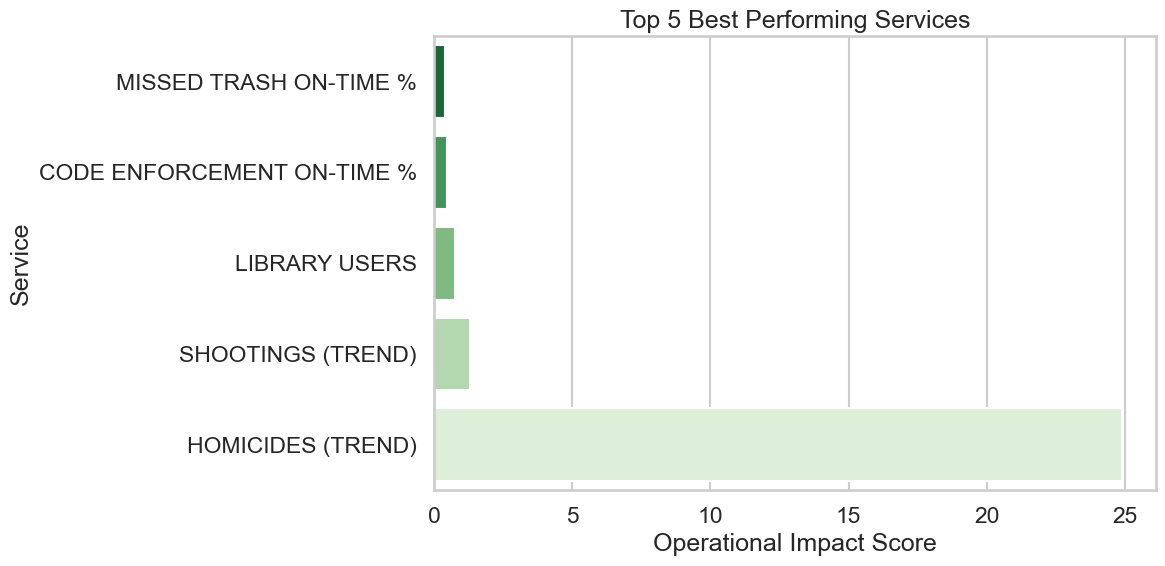

In [98]:
plot_top = top_5_services.sort_values("impact_score")
plt.figure(figsize=(12, 6))
sns.barplot(
    data=plot_top,
    x="impact_score",
    y="metric_name",
    hue="metric_name",
    dodge=False,
    palette="Greens_r",
    legend=False,
)
plt.title("Top 5 Best Performing Services")
plt.xlabel("Operational Impact Score")
plt.ylabel("Service")
plt.tight_layout()
plt.show()
        


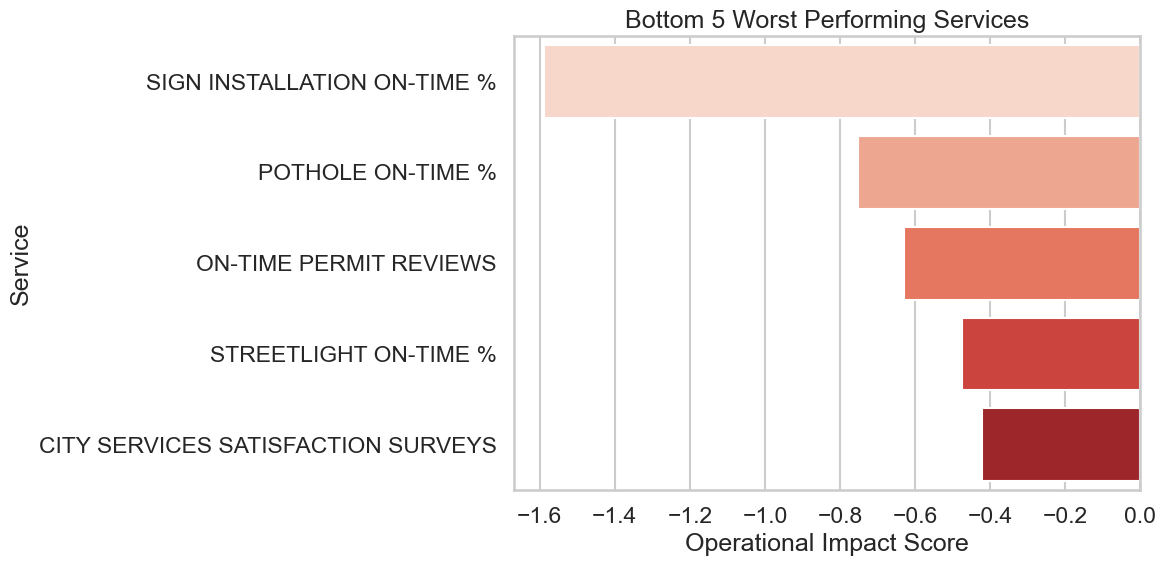

In [99]:
plot_bottom = bottom_5_services.sort_values("impact_score", ascending=True)
plt.figure(figsize=(12, 6))
sns.barplot(
    data=plot_bottom,
    x="impact_score",
    y="metric_name",
    hue="metric_name",
    dodge=False,
    palette="Reds",
    legend=False,
)
plt.title("Bottom 5 Worst Performing Services")
plt.xlabel("Operational Impact Score")
plt.ylabel("Service")
plt.tight_layout()
plt.show()
        


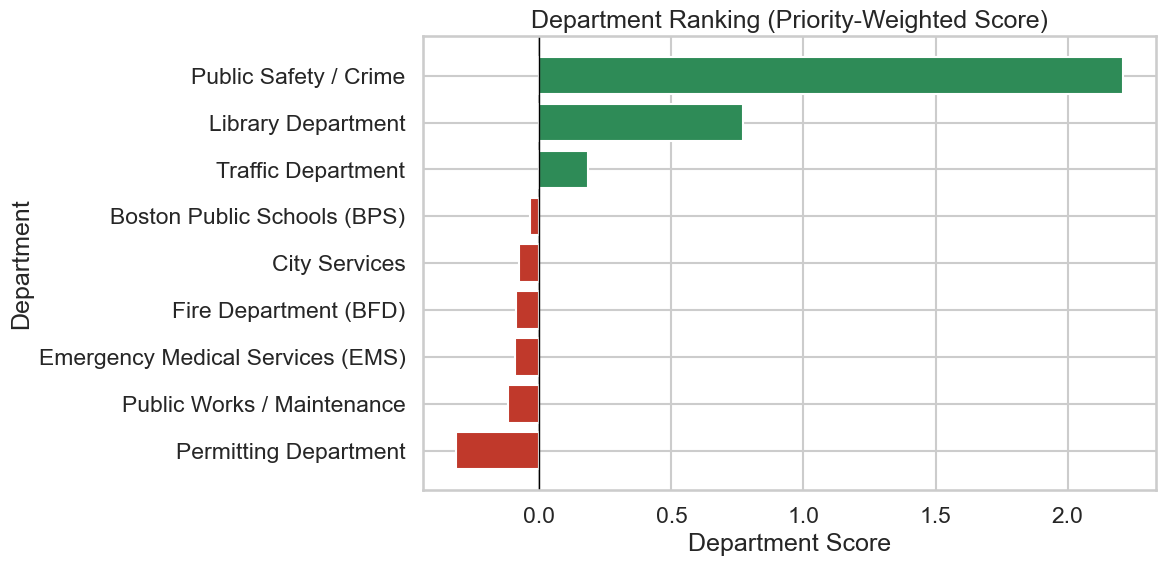

In [100]:
plot_departments = department_score_table.sort_values("department_score")
colors = ["#2e8b57" if score >= 0 else "#c0392b" for score in plot_departments["department_score"]]

plt.figure(figsize=(12, 6))
plt.barh(plot_departments["department"], plot_departments["department_score"], color=colors)
plt.axvline(0, color="black", linewidth=1)
plt.title("Department Ranking (Priority-Weighted Score)")
plt.xlabel("Department Score")
plt.ylabel("Department")
plt.tight_layout()
plt.show()
        


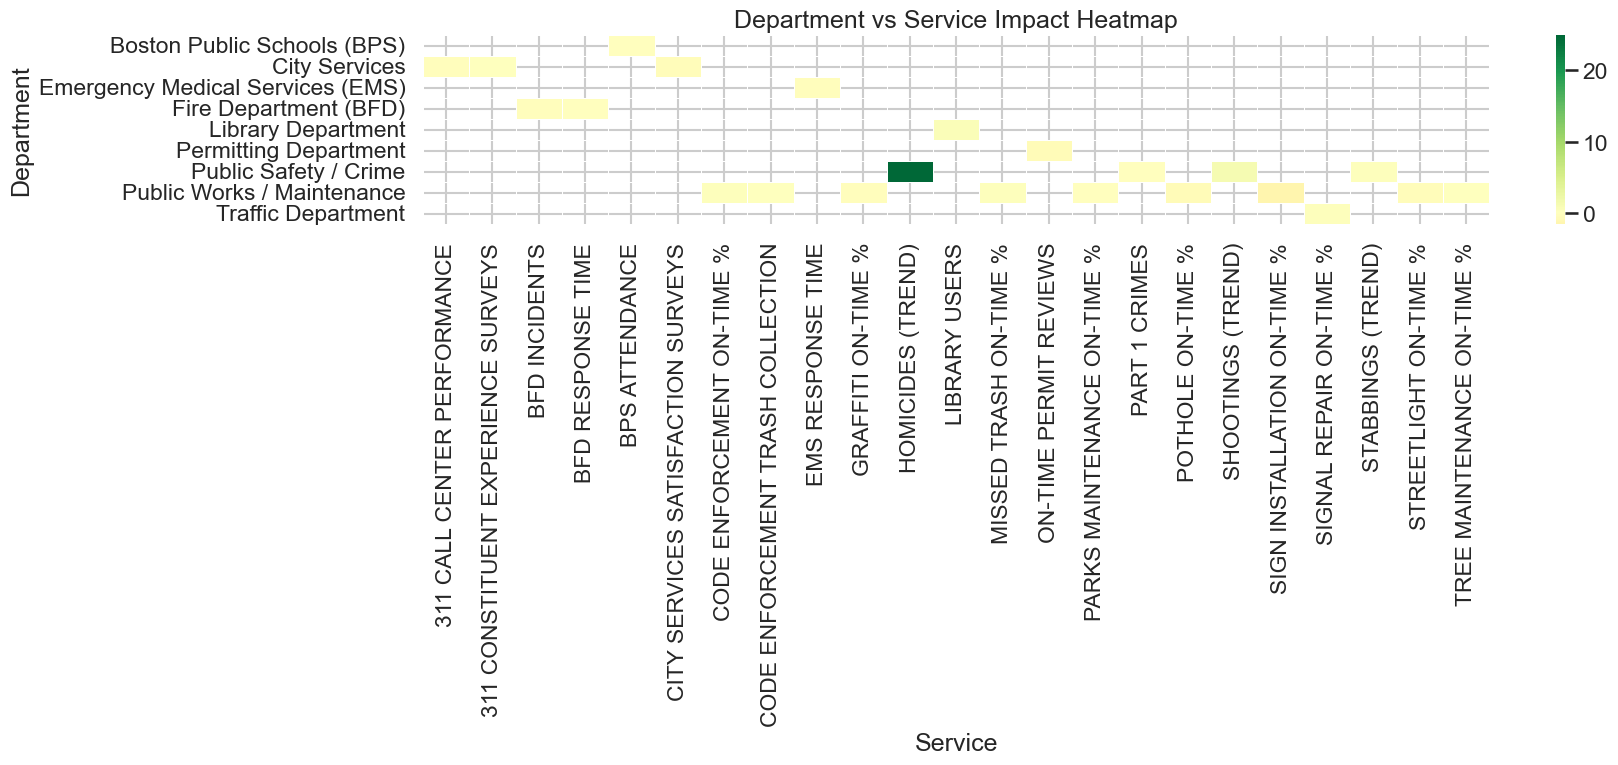

In [101]:
heatmap_data = service_kpi_table.pivot_table(
    index="department",
    columns="metric_name",
    values="impact_score",
    aggfunc="first",
)

plt.figure(figsize=(18, 8))
sns.heatmap(heatmap_data, cmap="RdYlGn", center=0, linewidths=0.5)
plt.title("Department vs Service Impact Heatmap")
plt.xlabel("Service")
plt.ylabel("Department")
plt.tight_layout()
plt.show()
        


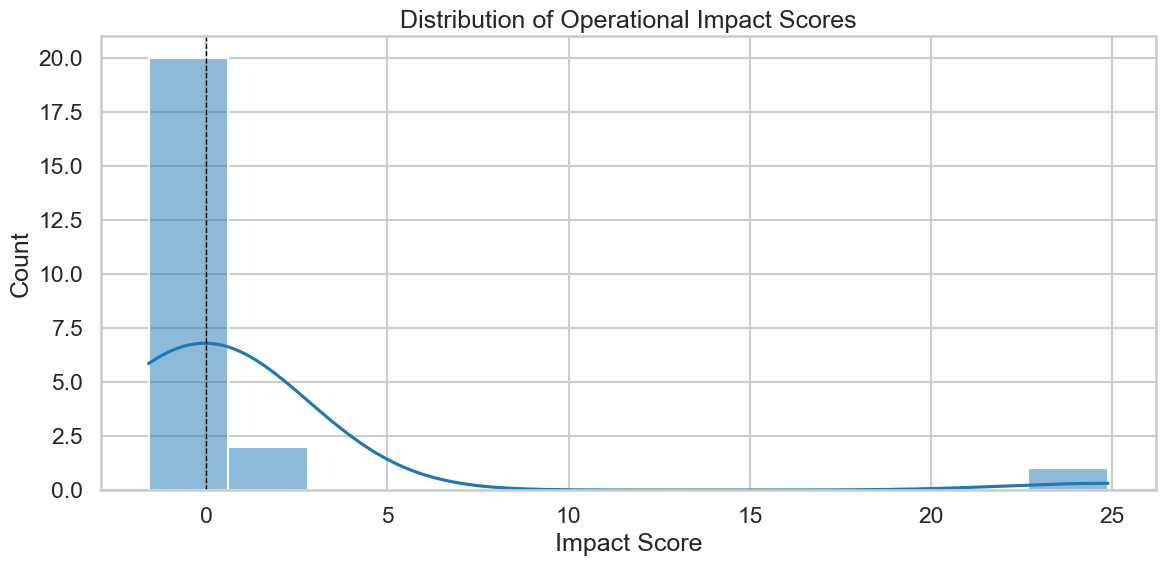

In [102]:
plt.figure(figsize=(12, 6))
sns.histplot(service_kpi_table["impact_score"], kde=True, bins=12, color="#1f77b4")
plt.axvline(0, color="black", linewidth=1, linestyle="--")
plt.title("Distribution of Operational Impact Scores")
plt.xlabel("Impact Score")
plt.ylabel("Count")
plt.tight_layout()
plt.show()
        


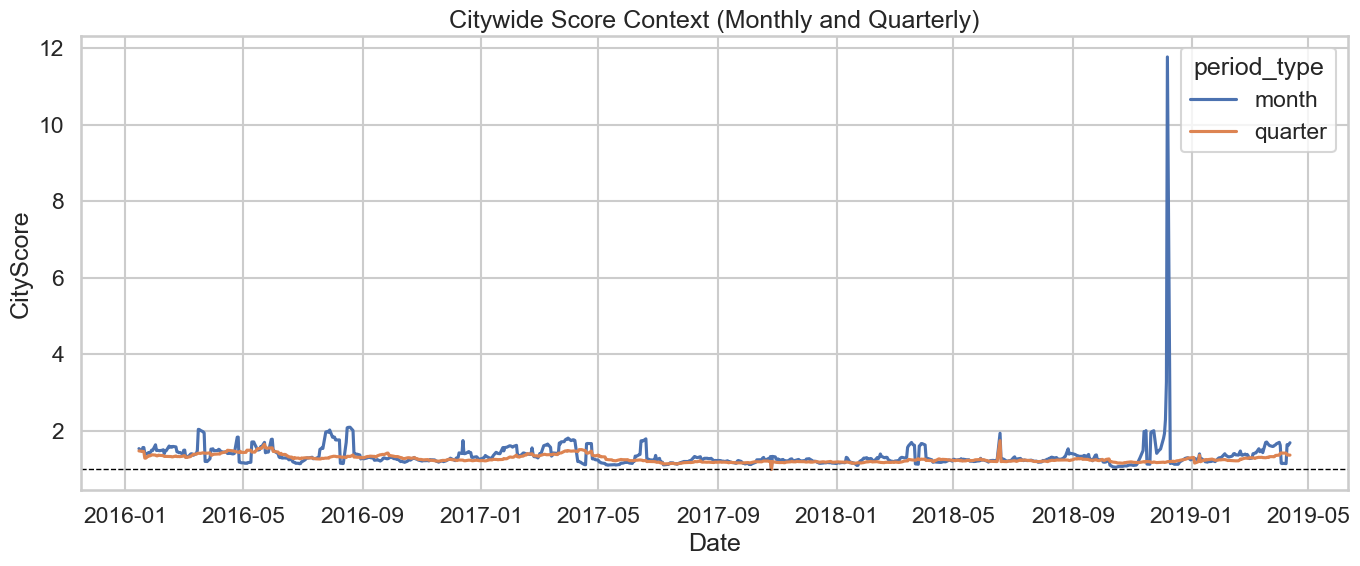

In [103]:
city_plot = citywide_history.loc[
    citywide_history["period_type"].isin(["month", "quarter"])
].sort_values("as_of_date")

plt.figure(figsize=(14, 6))
sns.lineplot(data=city_plot, x="as_of_date", y="score", hue="period_type")
plt.axhline(1.0, color="black", linewidth=1, linestyle="--")
plt.title("Citywide Score Context (Monthly and Quarterly)")
plt.xlabel("Date")
plt.ylabel("CityScore")
plt.tight_layout()
plt.show()
        


## Export Results

The notebook exports the required CSV files plus a multi-sheet Excel dashboard workbook to the `outputs/` folder.

In [104]:
export_targets = {
    "ranked_services.csv": service_kpi_table,
    "department_scores.csv": department_score_table,
    "top_5_services.csv": top_5_services,
    "bottom_5_services.csv": bottom_5_services,
}

for file_name, dataframe in export_targets.items():
    dataframe.to_csv(OUTPUT_DIR / file_name, index=False)

excel_dashboard_path = OUTPUT_DIR / "city_operational_dashboard.xlsx"
with pd.ExcelWriter(excel_dashboard_path, engine="openpyxl") as writer:
    export_frames = {
        "clean_merged_dataset": clean_merged_dataset,
        "service_kpi_table": service_kpi_table,
        "service_priority_table": service_priority_table,
        "operational_impact_scores": operational_impact_score_table,
        "department_scores": department_score_table,
        "top_5_services": top_5_services,
        "bottom_5_services": bottom_5_services,
        "best_departments": best_performing_departments,
        "worst_departments": worst_performing_departments,
        "critical_underperformers": critical_underperformers,
        "historical_metric_history": historical_metric_history,
        "citywide_history": citywide_history,
    }
    for sheet_name, dataframe in export_frames.items():
        safe_sheet_name = sheet_name[:31]
        dataframe.to_excel(writer, sheet_name=safe_sheet_name, index=False)
        autosize_worksheet(writer.sheets[safe_sheet_name], dataframe)

exported_files = pd.DataFrame(
    {
        "output_file": [
            OUTPUT_DIR / "ranked_services.csv",
            OUTPUT_DIR / "department_scores.csv",
            OUTPUT_DIR / "top_5_services.csv",
            OUTPUT_DIR / "bottom_5_services.csv",
            excel_dashboard_path,
        ]
    }
)
exported_files["exists"] = exported_files["output_file"].map(Path.exists)
display(exported_files)

,output_file,exists
0,/Users/ameyasutar1gmail.com/Desktop/IIMA/pytho...,True
1,/Users/ameyasutar1gmail.com/Desktop/IIMA/pytho...,True
2,/Users/ameyasutar1gmail.com/Desktop/IIMA/pytho...,True
3,/Users/ameyasutar1gmail.com/Desktop/IIMA/pytho...,True
4,/Users/ameyasutar1gmail.com/Desktop/IIMA/pytho...,True


## Final Conclusions

This final cell turns the ranking tables into a short executive summary that answers the core business questions:

- Which services are performing best?
- Which services are performing worst?
- Which departments are strongest overall?
- Which departments require intervention?
- Which critical services are underperforming?

In [105]:
best_service = top_5_services.iloc[0]
worst_service = bottom_5_services.iloc[0]
best_department = department_score_table.iloc[0]
worst_department = department_score_table.iloc[-1]

critical_list = ", ".join(critical_underperformers["metric_name"].tolist()) if not critical_underperformers.empty else "None"

summary_markdown = f"""
### Executive Summary

- **Best performing service:** `{best_service['metric_name']}` with an impact score of `{best_service['impact_score']:.4f}`.
- **Worst performing service:** `{worst_service['metric_name']}` with an impact score of `{worst_service['impact_score']:.4f}`.
- **Strongest department overall:** `{best_department['department']}` with a department score of `{best_department['department_score']:.4f}`.
- **Department requiring the most intervention:** `{worst_department['department']}` with a department score of `{worst_department['department_score']:.4f}`.
- **Critical underperforming services:** {critical_list}.

Ranking outputs have been exported to `{OUTPUT_DIR}` for downstream reporting and presentation use.
"""

display(Markdown(summary_markdown))


### Executive Summary

- **Best performing service:** `HOMICIDES (TREND)` with an impact score of `24.8803`.
- **Worst performing service:** `SIGN INSTALLATION ON-TIME %` with an impact score of `-1.5895`.
- **Strongest department overall:** `Public Safety / Crime` with a department score of `2.2080`.
- **Department requiring the most intervention:** `Permitting Department` with a department score of `-0.3147`.
- **Critical underperforming services:** EMS RESPONSE TIME, BFD INCIDENTS, 311 CALL CENTER PERFORMANCE, PART 1 CRIMES.

Ranking outputs have been exported to `/Users/ameyasutar1gmail.com/Desktop/IIMA/python/Boston Home Assignment/outputs` for downstream reporting and presentation use.
